# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# Ver la distribución de valores y el conteo de nulos
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

In [12]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


In [13]:

usage[
    usage['duration'].notna() &
    usage['length'].notna()
]

,id,user_id,type,date,duration,length
1414,1415,10399,text,2024-01-07 09:33:51.260781519,120.00,65.0
1824,1825,12936,text,2024-01-09 06:05:28.868221705,120.00,40.0
1932,1933,10189,text,2024-01-09 17:49:13.603840096,120.00,69.0
2070,2071,13139,call,2024-01-10 08:48:27.432685817,1.68,1490.0
2972,2973,10085,text,2024-01-14 10:46:02.169054226,120.00,68.0
5272,5273,11750,call,2024-01-24 20:33:12.649816245,3.78,1490.0
10614,10615,13855,call,2024-02-18 00:42:33.183829595,0.53,1490.0
11456,11457,13325,text,2024-02-21 20:09:09.733743343,120.00,23.0
12692,12693,12263,call,2024-02-27 10:23:08.374709367,1.80,1490.0
16702,16703,10484,text,2024-03-16 13:52:57.169429235,120.00,48.0


In [14]:
usage[
    (usage['duration'] == 120) |
    (usage['length'] == 1490)
]

,id,user_id,type,date,duration,length
992,993,10869,text,2024-01-05 11:44:02.016050401,NaN,1490.0
1414,1415,10399,text,2024-01-07 09:33:51.260781519,120.00,65.0
1824,1825,12936,text,2024-01-09 06:05:28.868221705,120.00,40.0
1932,1933,10189,text,2024-01-09 17:49:13.603840096,120.00,69.0
2070,2071,13139,call,2024-01-10 08:48:27.432685817,1.68,1490.0
2832,2833,13953,call,2024-01-13 19:33:46.400660016,120.00,NaN
2894,2895,11589,call,2024-01-14 02:17:46.526663166,120.00,NaN
2972,2973,10085,text,2024-01-14 10:46:02.169054226,120.00,68.0
3038,3039,10381,text,2024-01-14 17:56:06.174154353,NaN,1490.0
3986,3987,13493,call,2024-01-19 00:53:25.520138003,120.00,NaN


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

En el caso de DF users, contamos con 2 columnas con nulos. La columna **churn_date** presenta un 88.35% de valores nulos. No se consideran datos faltantes problemáticos, ya que es razonable asumir que los clientes activos no poseen una fecha de cancelación. La columna **city** presenta 469 valores nulos (11.7% de los registros). Adicionalmente, mediante value_counts() se identificaron 96 registros con el valor "?", el cual podría estar siendo utilizado como un marcador para datos faltantes o desconocidos. Este valor requerirá una investigación adicional para determinar si debe tratarse como un valor nulo durante la etapa de limpieza.

En el DF usage, la columna **date** presenta únicamente 50 valores nulos (0.125% del total). Se investigaron los registros afectados buscando patrones relacionados con el tipo de uso, usuario y otras variables, sin encontrarse una causa evidente. Debido a que representan una proporción muy pequeña del conjunto de datos, estos registros podrían eliminarse durante la etapa de limpieza sin afectar significativamente el análisis.

Las columnas **duration y length** presentan un alto porcentaje de valores nulos (55.19% y 44.74%, respectivamente). Sin embargo, al analizar la variable type, se observó que el conjunto de datos contiene dos tipos de registros: call y text.

Los registros de tipo call contienen información en la columna **duration**, mientras que la columna **length** permanece vacía. Por otro lado, los registros de tipo text contienen información en la columna **length**, mientras que la columna **duration** permanece vacía. Por lo tanto, estos valores nulos son consistentes con la naturaleza de los datos y no representan información faltante, por lo que no requieren imputación ni eliminación.

Adicionalmente, se identificaron **28 registros** en los que ambas columnas contienen valores simultáneamente. Al inspeccionarlos, se observó que la columna que no corresponde al tipo de registro fue rellenada con valores específicos que coinciden con los máximos de cada variable (120 para duration y 1490 para length). Este comportamiento sugiere la posible presencia de valores sentinel utilizados por el sistema para marcar registros especiales o inconsistentes, por lo que se recomienda investigarlos durante la fase de limpieza de datos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [15]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` no muestra indicios de valores inválidos. Los identificadores se encuentran dentro del rango esperado (10,000 a 13,999) y los valores elevados explican las altas magnitudes observadas en la media, desviación estándar y percentiles. Debido a que se trata de una variable identificadora, estas estadísticas no aportan información relevante sobre el comportamiento de los clientes.
- La columna `age` presenta un valor mínimo de -999 años, lo que representa un valor imposible y sugiere la presencia de un valor sentinel utilizado para indicar información faltante o errónea. Este registro afecta significativamente la media y la desviación estándar de la variable, provocando que la distribución se sesgue hacia la izquierda. Sin considerar este valor, los percentiles muestran edades consistentes entre 32 y 63 años, mientras que la edad máxima observada es de 79 años.

In [16]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` no presenta indicios de valores inválidos. Los identificadores abarcan el rango esperado de 1 a 40,000 y las estadísticas descriptivas observadas corresponden al comportamiento normal de una variable identificadora.
- La columna `user_id`tampoco muestra valores sospechosos. Los identificadores se encuentran dentro del rango esperado (10,000 a 13,999) y las estadísticas descriptivas reflejan únicamente la distribución de dichos identificadores.
- Las columna `duration` presenta una distribución en la que el 75% de los registros tiene una duración menor o igual a 6.99 minutos, mientras que el valor máximo alcanza los 120 minutos. Inicialmente este valor máximo puede considerarse atípico debido a su gran diferencia respecto al resto de la distribución. Además, durante la exploración se identificaron registros de tipo text con una duración de 120 minutos, lo que resulta inconsistente con la naturaleza de un mensaje de texto y sugiere que este valor podría estar siendo utilizado como un valor sentinel.
- La columna `length` presenta un comportamiento similar. El 75% de los mensajes tiene una longitud menor o igual a 64 caracteres, mientras que el valor máximo observado es de 1490 caracteres. Se detectaron registros de tipo call donde la columna length contiene precisamente este valor máximo, lo que resulta inconsistente para una llamada telefónica. Este patrón sugiere que el valor 1490 podría corresponder a un valor sentinel utilizado por el sistema.
- Se identificaron 28 registros donde las columnas duration y length contienen valores simultáneamente. En estos casos, la columna que no corresponde al tipo de evento (call o text) contiene los valores extremos de la distribución (120 y 1490). Debido a este comportamiento repetitivo e inconsistente con las reglas de negocio, estos valores se consideran posibles sentinels y deberán evaluarse durante la etapa de limpieza de datos.

In [17]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].value_counts()

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

La exploración de las variables categóricas `city` y `plan` permitió identificar dos planes disponibles (Basico y Premium) y seis ciudades principales (Bogotá, CDMX, Medellín, GDL, MTY y Cali).

No se observan errores ortográficos ni categorías duplicadas que sugieran problemas de consistencia en los nombres de ciudades o planes. Sin embargo, se identificaron 65 registros donde la ciudad aparece como "?" y 31 registros donde la ciudad se encuentra como una cadena vacía (""). Estos valores son consistentes con los hallazgos previos sobre la calidad de la columna city y podrían representar valores faltantes codificados de forma distinta a NaN.

En cuanto a la distribución, el plan Basico presenta una mayor cantidad de clientes que el plan Premium, mientras que las ciudades con mayor número de usuarios registrados son Bogotá y CDMX.

In [18]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` presenta únicamente dos categorías: text (22,092 registros) y call (17,908 registros). No se identificaron valores nulos ni categorías inesperadas, lo que sugiere una clasificación consistente de los eventos de uso. Además, se observa una mayor cantidad de mensajes de texto que de llamadas dentro del periodo analizado, representando aproximadamente el 55% y 45% de los registros, respectivamente.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

- En users, se detectó el valor -999 en la columna age, el cual representa una edad imposible y probablemente fue utilizado para indicar información faltante.
- Asimismo, en la columna city se encontraron distintas representaciones de datos ausentes, incluyendo valores NaN, el símbolo "?" y cadenas vacías, lo que evidencia una falta de estandarización en el registro de la información.
- Por otro lado, en usage se confirmó que los valores nulos de las columnas duration y length son consistentes con la naturaleza de los datos, ya que las llamadas únicamente utilizan duration y los mensajes de texto únicamente utilizan length, por lo que estos nulos no requieren tratamiento.
- Sin embargo, se detectaron valores extremos recurrentes (120 en duration y 1490 en length) que aparecen en registros donde dichas variables no deberían contener información. Además, se encontraron 28 registros con ambas columnas completas, donde la variable que no corresponde al tipo de evento contiene precisamente estos valores máximos.
- Este patrón sugiere que dichos valores podrían estar siendo utilizados como sentinels por el sistema. Como acción recomendada, se propone convertir los valores inválidos y sentinels identificados a NaN para posteriormente tratarlos de manera consistente durante la etapa de limpieza de datos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [19]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [20]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [21]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`: 
- La mayoría de los registros de alta se concentran entre 2022 y 2024.
- Se detectaron 40 registros con fecha de registro en 2026, lo cual resulta inconsistente dado que el análisis está limitado a información hasta 2024.
- Estos registros deberán investigarse durante la etapa de limpieza, ya que podrían representar errores de captura o fechas inválidas.

In [22]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

En `date`:
- Todos los registros válidos pertenecen al año 2024.
- Los 50 registros restantes corresponden a valores NaT, previamente identificados como fechas faltantes.
- No se observaron años fuera del periodo de análisis en esta tabla.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

- Se identificaron 40 registros con fecha de registro en 2026 dentro de users, un año que se encuentra fuera del periodo de análisis (hasta 2024), por lo que estos valores pueden considerarse fechas inválidas o errores de captura.
- En usage no se detectaron años fuera de rango, ya que todos los registros válidos corresponden a 2024. Se cuenta con 50 registros en NaT
- Como acción recomendada, se sugiere revisar los registros de 2026 y, si no es posible validar la fecha correcta, reemplazarlos por NaT o excluirlos del análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [23]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, np.nan)
users['age'] = users['age'].fillna(users['age'].median())

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [24]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', None)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      828
CDMX        747
Medellín    631
NaN         482
GDL         464
Cali        437
MTY         411
Name: city, dtype: int64

In [25]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = np.nan

# Verificar cambios
print(users['reg_date'].isna().sum())
users['reg_date'].dt.year.value_counts()

40


2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [26]:
# Verificación MAR en usage (Missing At Random) para duration
# Calcular el porcentaje de nulos en duration agrupado por type
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [27]:
# Verificación MAR en usage (Missing At Random) para length
# Calcular el porcentaje de nulos en duration agrupado por type
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

- Siguiendo la metodología de análisis de patrones de ausentes, calculamos la proporción de nulos en `duration` y `length` agrupados por la variable type:

- Para `duration`, el 99.93% de los registros de tipo text son nulos, mientras que en call es del 0.00%.

- Para `length`, el 99.93% de los registros de tipo call son nulos, mientras que en text es del 0.00%.

Conclusión: Existe una dependencia casi absoluta entre la presencia de nulos y la categoría del evento, lo que confirma que los datos son MAR (Missing at Random). El margen restante corresponde a 28 registros atípicos que contienen datos en ambas columnas al mismo tiempo, los cuales deben ser tratados como anomalías en la etapa de limpieza.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes = ('is_text', 'sum'), 
    cant_llamadas = ('is_call', 'sum'), 
    cant_minutos_llamada = ('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(10)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01
5,10005,5,7,44.97
6,10006,3,5,28.39
7,10007,3,5,30.23
8,10008,5,5,28.85
9,10009,5,3,5.99


In [29]:
# Renombrar columnas

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on= 'user_id', how= 'left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,Medellín,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [32]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

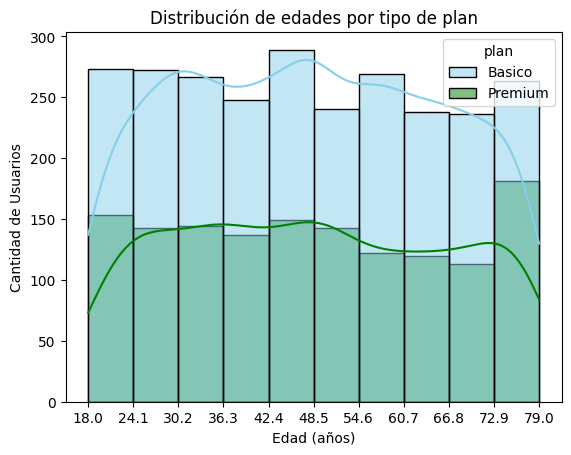

In [33]:
# 1. Calcular los límites/bordes exactos de los 12 bins
bin_edges = np.histogram_bin_edges(user_profile['age'].dropna(), bins=10)

# 2. Generar el histograma pasando explícitamente los bordes calculados
sns.histplot(data=user_profile, 
             x='age', 
             bins=bin_edges,  # Usamos la lista de bordes en lugar del número entero
             hue='plan', 
             palette=['skyblue', 'green'], 
             kde=True)

# 3. Forzar a que las marcas del eje X sean exactamente los bordes de los bins
plt.xticks(bin_edges)

plt.title('Distribución de edades por tipo de plan')
plt.xlabel('Edad (años)')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- La distribución de edades es relativamente uniforme entre los 18 y 79 años, sin concentraciones marcadas en un rango específico. Se observa una ligera mayor concentración de usuarios del plan Premium entre los 73 y 79 años, mientras que el rango de 42 a 48 años reúne la mayor cantidad de usuarios considerando ambos planes. Sin embargo, las distribuciones de los planes Básico y Premium son muy similares a lo largo de todos los rangos de edad, por lo que no se identifica una relación clara entre la edad del cliente y el plan contratado. En general, la distribución presenta un comportamiento aproximadamente uniforme, sin sesgos evidentes hacia edades jóvenes o mayores.

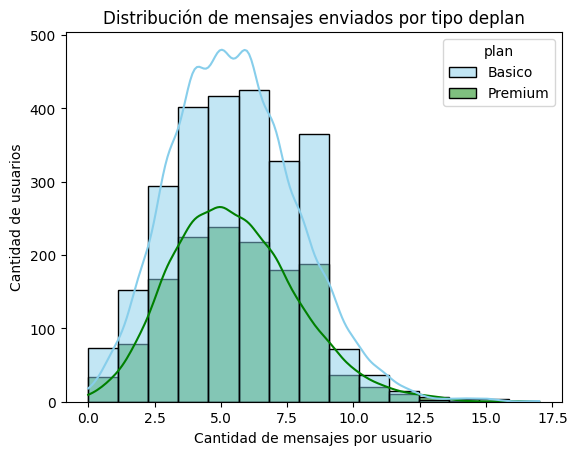

In [34]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data = user_profile, 
             x = 'cant_mensajes',
             bins= 15,
             hue= 'plan', 
             palette= ['skyblue', 'green'], 
             kde=True)

plt.title('Distribución de mensajes enviados por tipo deplan')
plt.xlabel('Cantidad de mensajes por usuario')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Dentro del plan Básico, existe una mayor proporción de usuarios que tienden a enviar entre 4 y 7 mensajes, mientras que los usuarios del plan Premium se concentran principalmente en un rango menor, de 3 a 5 mensajes.
- Ambos planes presentan una distribución sesgada a la derecha, lo que indica que la mayoría de los clientes realiza un uso moderado del servicio de mensajería, mientras que una pequeña minoría en ambos grupos envía una cantidad atípica de mensajes, alcanzando valores de hasta 17 mensajes. 

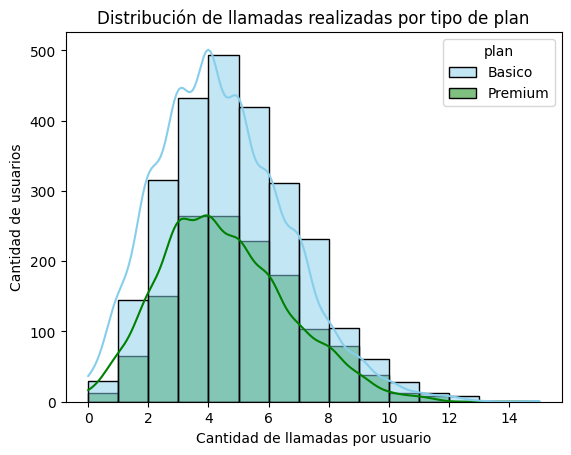

In [35]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data = user_profile, 
             x = 'cant_llamadas',
             bins= 15,
             hue= 'plan', 
             palette= ['skyblue', 'green'], 
             kde=True)

plt.title('Distribución de llamadas realizadas por tipo de plan')
plt.xlabel('Cantidad de llamadas por usuario')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 
- Dentro del plan Básico, se observa una mayor proporción de usuarios concentrados en el rango de 3 a 6 llamadas, alcanzando su punto máximo entre 4 y 5 llamadas. Por otro lado, los usuarios del plan Premium muestran un comportamiento muy similar, concentrándose principalmente entre 3 y 5 llamadas.
- Ambos planes presentan una distribución sesgada a la derecha, donde la mayoría de los usuarios realiza un número moderado de llamadas, mientras que una pequeña proporción de clientes en ambos grupos se extiende hacia la cola derecha con hasta 13 o 15 llamadas.

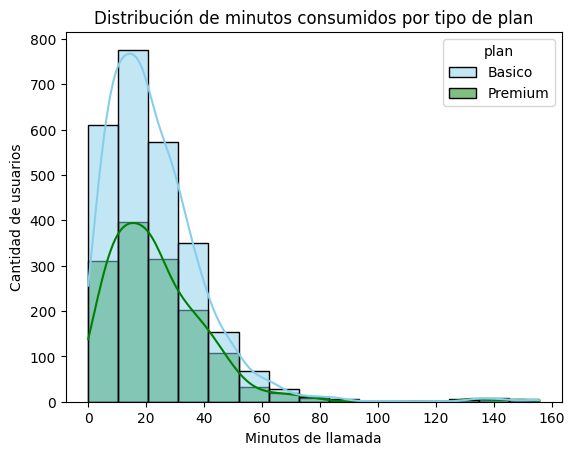

In [36]:

# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data = user_profile, 
             x = 'cant_minutos_llamada',
             bins= 15,
             hue= 'plan', 
             palette= ['skyblue', 'green'],
 
             kde=True)

plt.title('Distribución de minutos consumidos por tipo de plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 
- Dentro de ambos planes, la mayor proporción de usuarios se concentra en un rango bajo de consumo, principalmente entre 10 y 20 minutos de llamada (con un pico secundario notable entre 0 y 10 minutos). Ambos grupos presentan una distribución fuertemente sesgada a la derecha, donde el consumo disminuye rápidamente a partir de los 40 minutos, manteniendo una cola larga con un número reducido de usuarios atípicos que alcanzan hasta los 160 minutos consumidos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

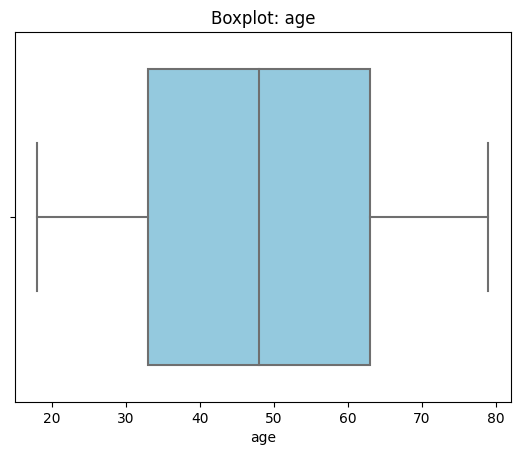

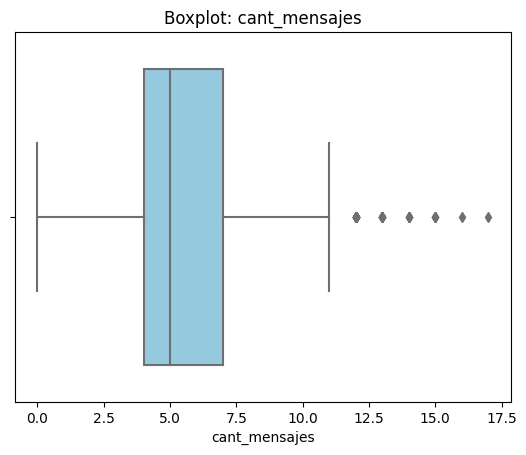

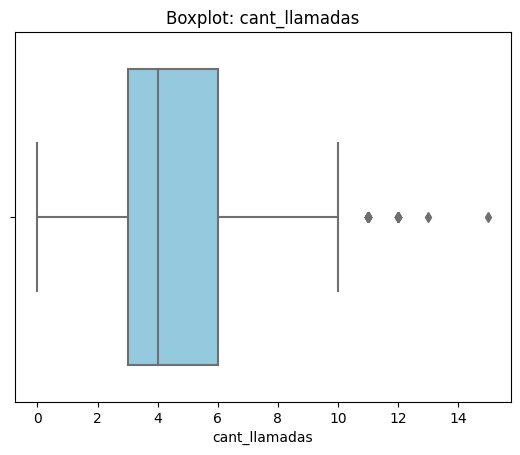

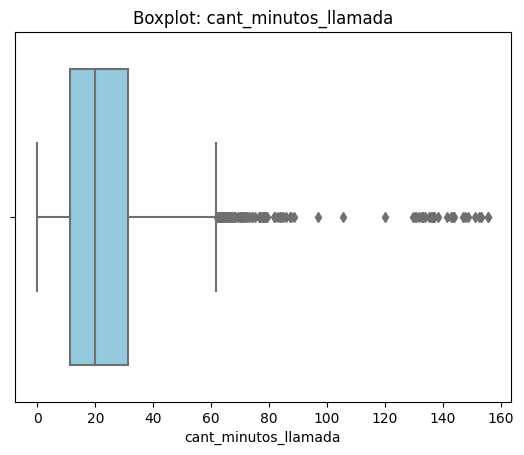

In [37]:
# Visualizando usando BoxPlot 

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x= user_profile[col], color= 'skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights: 
- Age: Como podemos observar en el boxplot y previamente analizamos en el histograma, la columna `age` no presenta outliers
- cant_mensajes: El boxplot muestra la presencia de valores atípicos por encima del límite superior calculado mediante el método IQR (11.5 mensajes). Los outliers se concentran entre 12 y 17 mensajes, lo que indica la existencia de un pequeño grupo de usuarios con una actividad de mensajería más intensa que la mayoría.
- cant_llamadas: Presenta algunos valores atípicos por encima del límite superior de 10.5 llamadas. Los registros identificados alcanzan hasta 15 llamadas por usuario y representan casos de uso más intensivo que el comportamiento típico
- cant_minutos_llamada: resenta una cantidad considerable de valores atípicos por encima del límite superior de 61.86 minutos, alcanzando hasta 155.69 minutos. Esto confirma la fuerte asimetría observada previamente en los histogramas y evidencia la existencia de usuarios con un consumo de llamadas significativamente superior al promedio.

In [38]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    # Calcular Q1, Q3 e IQR
    Q1 = user_profile[col].quantile(0.25)
    Q3= user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    #Calcular límite upper
    upper = Q3 + 1.5 * IQR

    print(f'Límite de {col}')
    print('IQR: ', IQR)
    print('Límite superior: ', upper)
    print( )



Límite de cant_mensajes
IQR:  3.0
Límite superior:  11.5

Límite de cant_llamadas
IQR:  3.0
Límite superior:  10.5

Límite de cant_minutos_llamada
IQR:  20.295
Límite superior:  61.8575



In [39]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Presenta valores atípicos por encima del límite superior de 11.5 mensajes, alcanzando un máximo de 17. Sin embargo, estos valores no se consideran inválidos, ya que representan usuarios con un nivel de mensajería superior al promedio. Esto sugiere la existencia de un pequeño grupo de clientes más activos en el uso de mensajes de texto, mientras que la mayoría mantiene un comportamiento moderado.
  
- cant_llamadas: Muestra observaciones por encima del límite superior de 10.5 llamadas, con un máximo de 15. Estos registros no parecen corresponder a errores de captura, sino a usuarios con una frecuencia de llamadas mayor que la del resto de la población. La presencia de estos valores es consistente con la distribución sesgada a la derecha observada en los histogramas.

- cant_minutos_llamada: Presenta los valores atípicos más pronunciados, con observaciones que superan el límite superior de 61.86 minutos y alcanzan un máximo de 155.69 minutos. Durante la exploración previa se identificaron 16 registros (0.04% del total) correspondientes a mensajes de texto con un valor de duration = 120, el cual podría representar un valor sentinel y contribuir ligeramente a incrementar el total de minutos de algunos usuarios. Sin embargo, debido a su baja frecuencia, se considera que su impacto sobre la distribución general es mínimo. Por ello, los valores atípicos se mantienen al considerarse representativos de usuarios con un consumo intensivo de llamadas y coherentes con la distribución sesgada a la derecha observada en los histogramas.

In [40]:
usage[
    (usage['type'] == 'text') &
    (usage['duration'] == 120)
].shape[0]

16

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [46]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'Bajo Uso',
        np.where((user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 'Uso medio', 'Alto uso'))

In [47]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,Medellín,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo Uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [48]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(user_profile['age'] < 30, 'Joven',
                                     np.where(user_profile['age'] < 60, 'Adulto', 'Adulto Mayor'))

In [49]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,Medellín,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo Uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

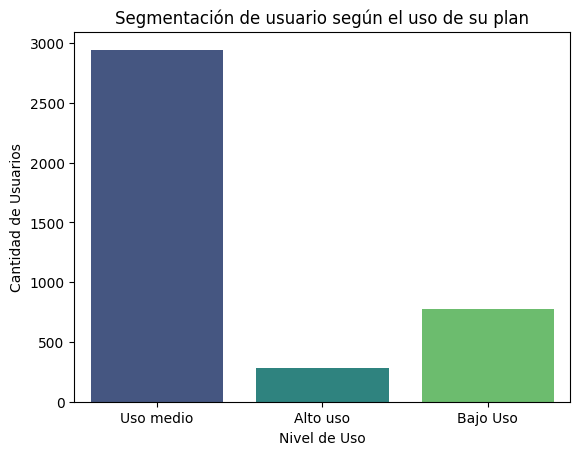

In [60]:
# Visualización de los segmentos por uso
sns.countplot(data= user_profile, x= user_profile['grupo_uso'], palette = 'viridis')
plt.xlabel('Nivel de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.title('Segmentación de usuario según el uso de su plan')

plt.show()

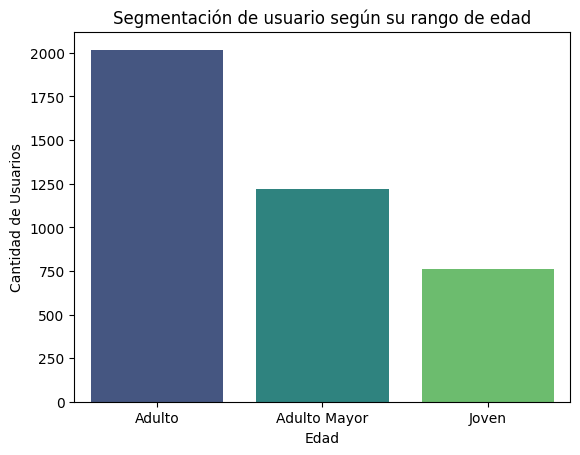

In [61]:
# Visualización de los segmentos por edad
sns.countplot(data= user_profile, x= user_profile['grupo_edad'], palette = 'viridis')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.title('Segmentación de usuario según su rango de edad')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo
Durante la fase de calidad de datos se identificaron diversos problemas que requirieron atención antes del análisis. En el dataset users se detectó un valor inválido de edad (-999), así como diferentes representaciones de datos faltantes en la columna city, incluyendo 469 valores nulos (11.7%), 65 registros con "?" y 31 registros vacíos. También se encontraron 40 usuarios con fecha de registro en 2026, un año fuera del periodo de análisis. En el dataset usage se detectaron posibles valores sentinel (120 en duration y 1490 en length) asociados a 30 registros, además de 50 fechas faltantes. Aunque estos problemas representan una pequeña proporción del total de registros, fue importante identificarlos para evitar interpretaciones erróneas.

Respecto a la segmentación de clientes, se clasificó a los usuarios por edad y nivel de uso. El segmento más numeroso corresponde a los Adultos (30-59 años), seguido por los Adultos Mayores (60+ años), mientras que los Jóvenes (<30 años) representan el grupo más pequeño. En cuanto al nivel de uso, la mayoría de los clientes pertenece al segmento de Uso Medio, seguido por los usuarios de Bajo Uso, mientras que los clientes de Alto Uso constituyen una minoría dentro de la base total.

Los segmentos más valiosos para ConnectaTel parecen ser los usuarios de Uso Medio y Alto Uso, ya que son quienes generan una mayor utilización de los servicios de llamadas y mensajería. En especial, los clientes de Alto Uso representan una oportunidad para estrategias de fidelización y planes premium con beneficios adicionales, ya que muestran un nivel de consumo superior al promedio.

Durante el análisis se identificaron valores atípicos en las variables cant_mensajes, cant_llamadas y cant_minutos_llamada. Sin embargo, estos registros no corresponden a errores evidentes de captura, sino a clientes con patrones de consumo más intensivos. En el caso de cant_minutos_llamada, algunos valores elevados podrían estar parcialmente influenciados por 16 registros (0.04% del total) que contienen un posible valor sentinel en la duración de mensajes, aunque su impacto general sobre la distribución es mínimo. Por esta razón, los outliers fueron conservados para representar adecuadamente el comportamiento real de los usuarios.

Como recomendación de negocio, ConnectaTel podría mantener una oferta competitiva para el segmento de Uso Medio, ya que concentra la mayor parte de la base de clientes. Asimismo, sería recomendable diseñar planes especializados para usuarios de Alto Uso, incorporando más minutos incluidos, beneficios exclusivos o programas de lealtad que ayuden a incrementar la retención. Para los usuarios de Bajo Uso, podrían ofrecerse planes más económicos o flexibles que eviten el abandono del servicio por falta de aprovechamiento. Finalmente, se recomienda fortalecer los procesos de captura y validación de datos para reducir la presencia de valores inválidos y mejorar la calidad de los análisis futuros.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`